In [1]:
import pandas as pd
data = pd.read_csv('/home/ubuntu/assignment3/data/lightcast_job_postings.csv')
data.head()

/tmp/ipykernel_3521/1223867133.py:2: DtypeWarning: Columns (0: COMPANY_IS_STAFFING, 1: IS_INTERNSHIP) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ubuntu/assignment3/data/lightcast_job_postings.csv')


,ID,LAST_UPDATED_DATE,LAST_UPDATED_TIMESTAMP,DUPLICATES,POSTED,EXPIRED,DURATION,SOURCE_TYPES,SOURCES,URL,...,NAICS_2022_2,NAICS_2022_2_NAME,NAICS_2022_3,NAICS_2022_3_NAME,NAICS_2022_4,NAICS_2022_4_NAME,NAICS_2022_5,NAICS_2022_5_NAME,NAICS_2022_6,NAICS_2022_6_NAME
0,1f57d95acf4dc67ed2819eb12f049f6a5c11782c,9/6/2024,2024-09-06 20:32:57.352 Z,0.0,6/2/2024,6/8/2024,6.0,"[\n ""Company""\n]","[\n ""brassring.com""\n]","[\n ""https://sjobs.brassring.com/TGnewUI/Sear...",...,44.0,Retail Trade,441.0,Motor Vehicle and Parts Dealers,4413.0,"Automotive Parts, Accessories, and Tire Retailers",44133.0,Automotive Parts and Accessories Retailers,441330.0,Automotive Parts and Accessories Retailers
1,0cb072af26757b6c4ea9464472a50a443af681ac,8/2/2024,2024-08-02 17:08:58.838 Z,0.0,6/2/2024,8/1/2024,NaN,"[\n ""Job Board""\n]","[\n ""maine.gov""\n]","[\n ""https://joblink.maine.gov/jobs/1085740""\n]",...,56.0,Administrative and Support and Waste Managemen...,561.0,Administrative and Support Services,5613.0,Employment Services,56132.0,Temporary Help Services,561320.0,Temporary Help Services
2,85318b12b3331fa490d32ad014379df01855c557,9/6/2024,2024-09-06 20:32:57.352 Z,1.0,6/2/2024,7/7/2024,35.0,"[\n ""Job Board""\n]","[\n ""dejobs.org""\n]","[\n ""https://dejobs.org/dallas-tx/data-analys...",...,52.0,Finance and Insurance,524.0,Insurance Carriers and Related Activities,5242.0,"Agencies, Brokerages, and Other Insurance Rela...",52429.0,Other Insurance Related Activities,524291.0,Claims Adjusting
3,1b5c3941e54a1889ef4f8ae55b401a550708a310,9/6/2024,2024-09-06 20:32:57.352 Z,1.0,6/2/2024,7/20/2024,48.0,"[\n ""Job Board""\n]","[\n ""disabledperson.com"",\n ""dejobs.org""\n]","[\n ""https://www.disabledperson.com/jobs/5948...",...,52.0,Finance and Insurance,522.0,Credit Intermediation and Related Activities,5221.0,Depository Credit Intermediation,52211.0,Commercial Banking,522110.0,Commercial Banking
4,cb5ca25f02bdf25c13edfede7931508bfd9e858f,6/19/2024,2024-06-19 07:00:00.000 Z,0.0,6/2/2024,6/17/2024,15.0,"[\n ""FreeJobBoard""\n]","[\n ""craigslist.org""\n]","[\n ""https://modesto.craigslist.org/sls/77475...",...,99.0,Unclassified Industry,999.0,Unclassified Industry,9999.0,Unclassified Industry,99999.0,Unclassified Industry,999999.0,Unclassified Industry


In [2]:
import os
import pandas as pd

# Crear carpeta output
os.makedirs('_output', exist_ok=True)

# Convertir fechas
data['POSTED'] = pd.to_datetime(data['POSTED'], errors='coerce')
data['EXPIRED'] = pd.to_datetime(data['EXPIRED'], errors='coerce')
data['LAST_UPDATED_DATE'] = pd.to_datetime(data['LAST_UPDATED_DATE'], errors='coerce')

# Convertir numéricos
data['SALARY_FROM'] = pd.to_numeric(data['SALARY_FROM'], errors='coerce')
data['SALARY_TO'] = pd.to_numeric(data['SALARY_TO'], errors='coerce')
data['MIN_YEARS_EXPERIENCE'] = pd.to_numeric(data['MIN_YEARS_EXPERIENCE'], errors='coerce')

# Rellenar NaN
data['SALARY_FROM'].fillna(0, inplace=True)
data['SALARY_TO'].fillna(0, inplace=True)
data['MIN_YEARS_EXPERIENCE'].fillna(0, inplace=True)

# Guardar
data.to_csv('_output/lightcast_cleaned.csv', index=False)

/tmp/ipykernel_3521/2565229630.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['SALARY_FROM'].fillna(0, inplace=True)
/tmp/ipykernel_3521/2565229630.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to up

## 1.2

In [3]:
print(data.columns)

Index(['ID', 'LAST_UPDATED_DATE', 'LAST_UPDATED_TIMESTAMP', 'DUPLICATES',
       'POSTED', 'EXPIRED', 'DURATION', 'SOURCE_TYPES', 'SOURCES', 'URL',
       ...
       'NAICS_2022_2', 'NAICS_2022_2_NAME', 'NAICS_2022_3',
       'NAICS_2022_3_NAME', 'NAICS_2022_4', 'NAICS_2022_4_NAME',
       'NAICS_2022_5', 'NAICS_2022_5_NAME', 'NAICS_2022_6',
       'NAICS_2022_6_NAME'],
      dtype='str', length=131)


In [4]:
[col for col in data.columns if 'STATE' in col]

['STATE', 'STATE_NAME']

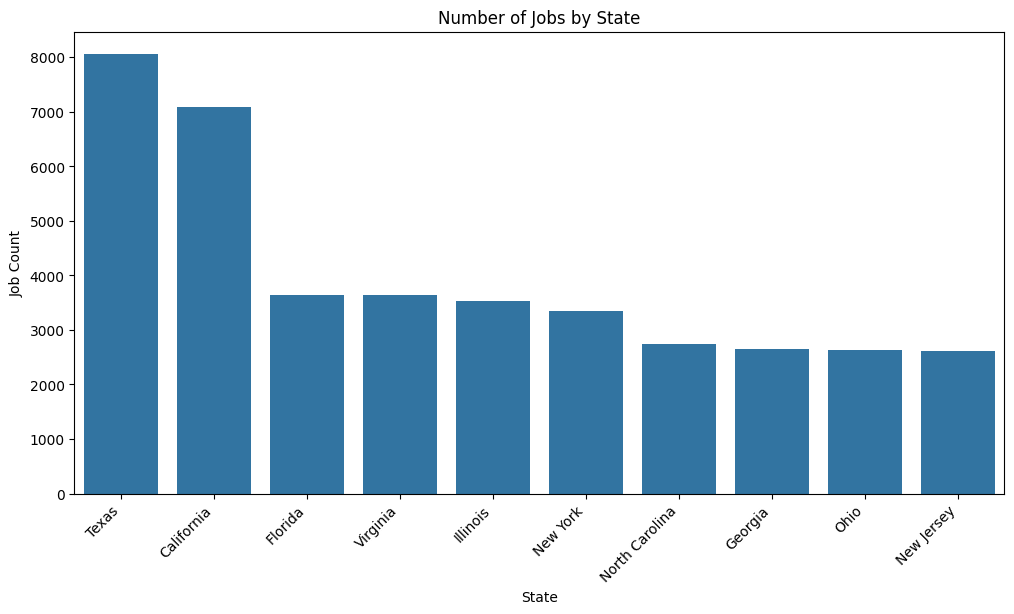

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por estado (nombre completo)
job_counts = data.groupby('STATE_NAME').size().reset_index(name='Job Count')

# Ordenar
job_counts = job_counts.sort_values(by='Job Count', ascending=False)

# (Opcional pero recomendado) Top 10
job_counts = job_counts.head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='STATE_NAME', y='Job Count', data=job_counts)

plt.xticks(rotation=45, ha='right')
plt.title('Number of Jobs by State')
plt.xlabel('State')
plt.ylabel('Job Count')

plt.show()

**Note:** The analysis uses the STATE_NAME column to provide a clearer and more interpretable representation of geographic distribution.

## Question 2: Jobs in a Specific Industry

In [6]:
data['NAICS_2022_2_NAME'].unique()

<ArrowStringArray>
[                                                            'Retail Trade',
 'Administrative and Support and Waste Management and Remediation Services',
                                                    'Finance and Insurance',
                                                    'Unclassified Industry',
                                                              'Information',
                                                            'Manufacturing',
                         'Professional, Scientific, and Technical Services',
                                                          'Wholesale Trade',
                                                     'Educational Services',
                                        'Health Care and Social Assistance',
                            'Other Services (except Public Administration)',
                                                    'Public Administration',
                                                         

In [7]:
job_counts.head()

,STATE_NAME,Job Count
42,Texas,8067
4,California,7084
8,Florida,3645
45,Virginia,3636
12,Illinois,3538


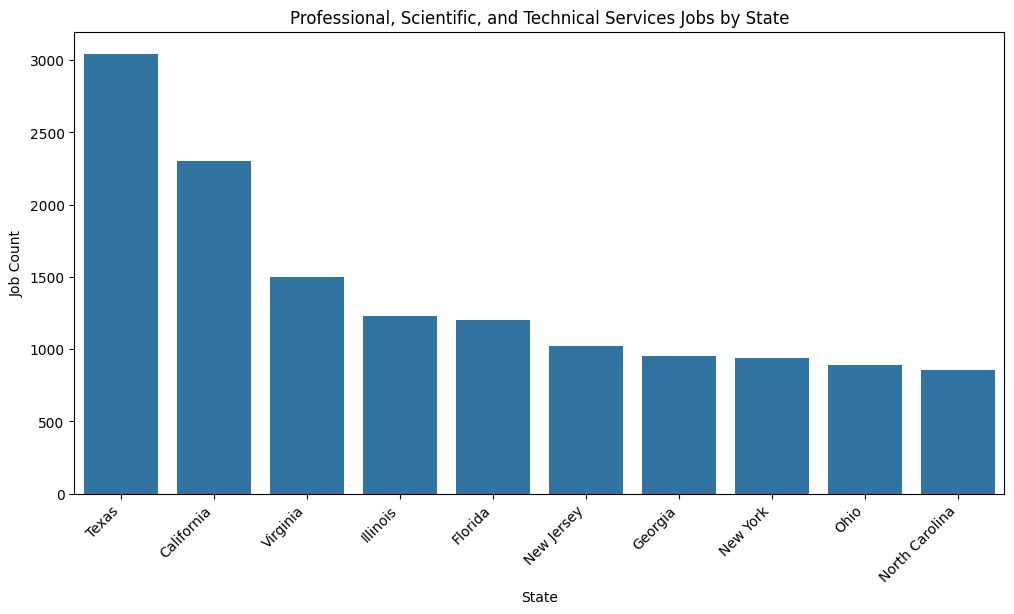

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Elegir industria (RECOMENDADA)
industry = 'Professional, Scientific, and Technical Services'

# Filtrar
industry_data = data[data['NAICS_2022_2_NAME'] == industry]

# Agrupar por estado
job_counts = industry_data.groupby('STATE_NAME').size().reset_index(name='Job Count')

# Ordenar y top 10
job_counts = job_counts.sort_values(by='Job Count', ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='STATE_NAME', y='Job Count', data=job_counts)

plt.xticks(rotation=45, ha='right')
plt.title(f'{industry} Jobs by State')
plt.xlabel('State')
plt.ylabel('Job Count')

plt.show()

**Insight:** Jobs in the Professional, Scientific, and Technical Services sector are heavily concentrated in a few key states, suggesting strong regional specialization in high-skill and knowledge-based industries. These areas likely benefit from advanced infrastructure, talent pools, and innovation ecosystems.

## Question 3: Percentage Change in Jobs for Specific Companies

In [9]:
data['COMPANY_NAME'].value_counts().head(10)

COMPANY_NAME
Unclassified              3984
Deloitte                  2554
Accenture                 1498
PricewaterhouseCoopers     839
KPMG                       451
Merit America              444
Insight Global             442
Lumen Technologies         424
Humana                     421
Oracle                     392
Name: count, dtype: int64

In [10]:
companies = ['Amazon', 'Google', 'Microsoft']

In [11]:
filtered = data[data['COMPANY_NAME'].isin(companies)]
filtered['month'] = filtered['POSTED'].dt.to_period('M')
may = filtered[filtered['month'] == '2024-05']
sept = filtered[filtered['month'] == '2024-09']
count_may = may.groupby('COMPANY_NAME').size()
count_sept = sept.groupby('COMPANY_NAME').size()
percent_change = ((count_sept - count_may) / count_may) * 100
percent_change = percent_change.reset_index(name='Percent Change')

percent_change


,COMPANY_NAME,Percent Change
0,Amazon,123.529412
1,Google,-83.783784
2,Microsoft,100.000000


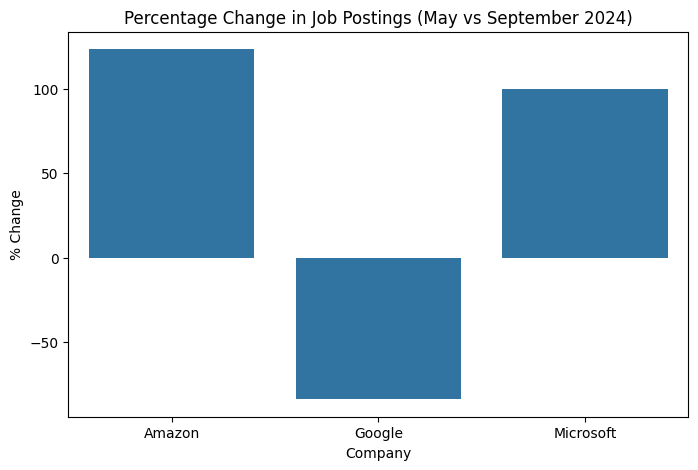

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x='COMPANY_NAME', y='Percent Change', data=percent_change)

plt.title('Percentage Change in Job Postings (May vs September 2024)')
plt.xlabel('Company')
plt.ylabel('% Change')

plt.show()

**Insight:** The percentage change in job postings varies significantly across companies, indicating different hiring strategies and growth trends. Some companies show strong expansion, while others maintain stable or reduced hiring activity over time.

## Question 4: Average Salary by Industry

In [13]:
data['AVG_SALARY'] = data[['SALARY_FROM', 'SALARY_TO']].mean(axis=1)
salary_by_industry = data.groupby('NAICS_2022_2_NAME')['AVG_SALARY'].mean().reset_index()
salary_by_industry = salary_by_industry.sort_values(by='AVG_SALARY', ascending=False)
salary_by_industry = salary_by_industry.head(10)

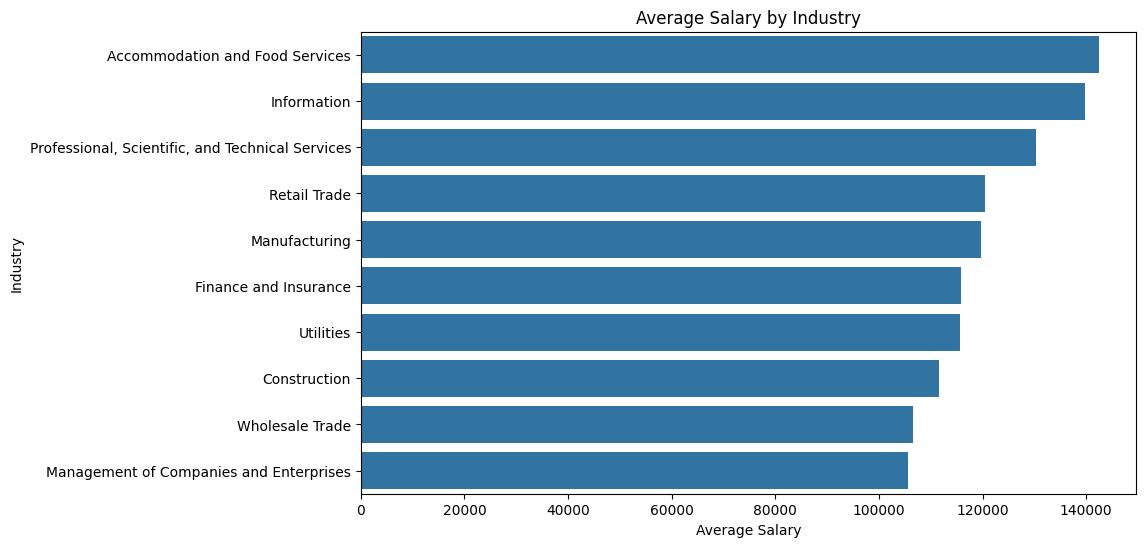

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    y='NAICS_2022_2_NAME',
    x='AVG_SALARY',
    data=salary_by_industry
)

plt.title('Average Salary by Industry')
plt.xlabel('Average Salary')
plt.ylabel('Industry')

plt.show()

**Insight:** Average salaries vary significantly across industries, with high-skill sectors such as Professional, Scientific, and Technical Services offering higher compensation. This reflects the demand for specialized knowledge and advanced expertise in these fields.

In [15]:
salary_by_industry

,NAICS_2022_2_NAME,AVG_SALARY
0,Accommodation and Food Services,142446.000000
8,Information,139714.552419
13,"Professional, Scientific, and Technical Services",130406.244613
16,Retail Trade,120497.915737
10,Manufacturing,119645.955747
6,Finance and Insurance,115897.086843
19,Utilities,115637.721574
4,Construction,111623.613712
20,Wholesale Trade,106595.983033
9,Management of Companies and Enterprises,105693.914634


## Question 5: Skills Distribution in Job Postings

In [16]:
print('SKILLS' in data.columns)

True


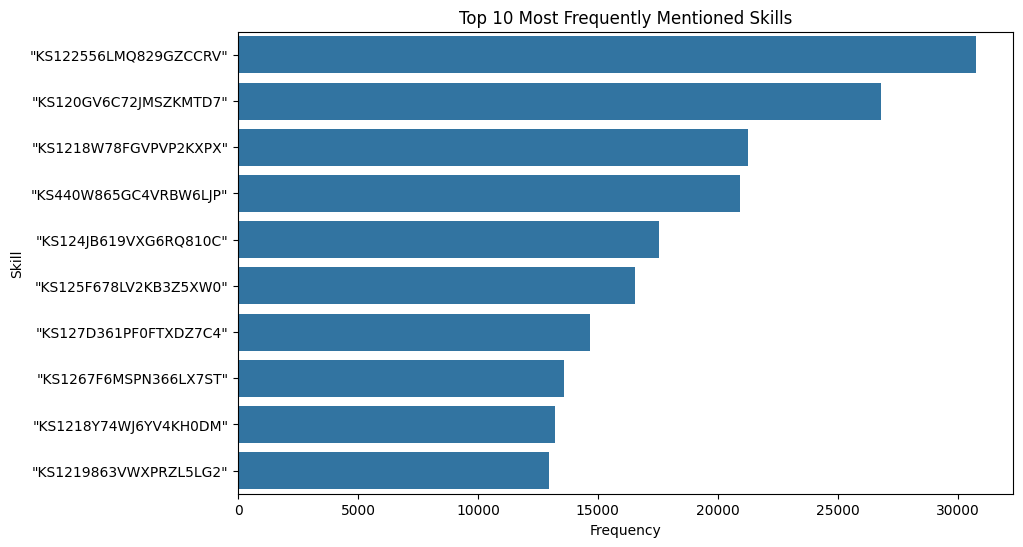

In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extraer skills
skills_series = data['SKILLS'].dropna()

# Separar y convertir a filas
skills_exploded = skills_series.str.split(',').explode()

# Limpiar espacios
skills_exploded = skills_exploded.str.strip()

# Contar top 10
skill_counts = skills_exploded.value_counts().head(10)

# DataFrame
skill_df = skill_counts.reset_index()
skill_df.columns = ['Skill', 'Count']

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Count', y='Skill', data=skill_df)

plt.title('Top 10 Most Frequently Mentioned Skills')
plt.xlabel('Frequency')
plt.ylabel('Skill')

plt.show()

In [18]:
skill_df = skill_df.sort_values(by='Count', ascending=False)

**Insight:** The most frequently mentioned skills highlight the key competencies demanded in the job market. Technical and analytical skills dominate, indicating a strong demand for specialized knowledge and data-driven capabilities across industries.

In [19]:
# Q1
plt.savefig('_output/q1_job_count_by_state.png')

# Q2
plt.savefig('_output/q2_jobs_by_industry.png')

# Q3
plt.savefig('_output/q3_percentage_change.png')

# Q4
plt.savefig('_output/q4_salary_by_industry.png')

# Q5
plt.savefig('_output/q5_skills_distribution.png')

<Figure size 640x480 with 0 Axes>